In [18]:
# setup (https://keras.io/getting_started/intro_to_keras_for_engineers/)
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import requests
import time

# load Keras after backend (TensorFlow)
import tensorflow as tf
import keras
from keras import layers

from pathlib import Path
from urllib.parse import urlparse
from PIL import Image
from io import BytesIO

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1


In [19]:
# iNaturalist settings

API_URL = "https://api.inaturalist.org/v1/observations"

SINGAPORE_PLACE_ID = 6734

scientific_name = "Manis javanica"

params = {
    "taxon_name": scientific_name,
    "place_id": SINGAPORE_PLACE_ID,
    "quality_grade": "research",
    "photos": "true",
    "photo_license": "cc0,cc-by,cc-by-nc",
    "per_page": 10
}

response = requests.get(API_URL, params=params, timeout=30)
response.raise_for_status()

data = response.json()

print("Total matching observations:", data["total_results"])
print("Observations returned:", len(data["results"]))

Total matching observations: 58
Observations returned: 10


In [20]:
observation = data["results"][0]

print("Observation ID:", observation["id"])
print("Scientific name:", observation["taxon"]["name"])

photo = observation["photos"][0]

print("Photo ID:", photo["id"])
print("Licence:", photo["license_code"])
print("Attribution:", photo["attribution"])
print("Original API URL:", photo["url"])

Observation ID: 381875118
Scientific name: Manis javanica
Photo ID: 698793013
Licence: cc-by-nc
Attribution: (c) chugbug111, some rights reserved (CC BY-NC)
Original API URL: https://inaturalist-open-data.s3.amazonaws.com/photos/698793013/square.jpg


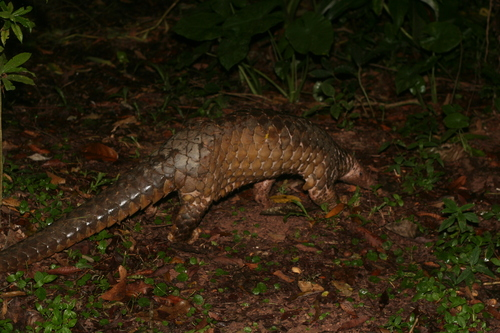

Original downloaded size: (500, 333)


In [21]:
image_response = requests.get(aws_url, timeout=30)
image_response.raise_for_status()

image = Image.open(BytesIO(image_response.content))
image = image.convert("RGB")

display(image)

print("Original downloaded size:", image.size)

In [22]:
def download_species_images(
    scientific_name,
    folder_name,
    target_images=100
):
    output_folder = Path("dataset") / folder_name
    output_folder.mkdir(parents=True, exist_ok=True)

    downloaded = 0
    page = 1
    metadata = []

    while downloaded < target_images:

        params = {
            "taxon_name": scientific_name,
            "place_id": SINGAPORE_PLACE_ID,
            "quality_grade": "research",
            "photos": "true",
            "photo_license": "cc0,cc-by,cc-by-nc",
            "per_page": 200,
            "page": page
        }

        response = requests.get(
            API_URL,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        if len(data["results"]) == 0:
            break

        for observation in data["results"]:

            if downloaded >= target_images:
                break

            # Use only one photo from each observation
            for photo in observation.get("photos", []):

                licence = photo.get("license_code")

                if licence not in {
                    "cc0",
                    "cc-by",
                    "cc-by-nc"
                }:
                    continue

                photo_id = photo["id"]

                extension = Path(
                    urlparse(photo["url"]).path
                ).suffix.replace(".", "")

                if extension == "":
                    extension = "jpg"

                aws_url = (
                    "https://inaturalist-open-data.s3.amazonaws.com/"
                    f"photos/{photo_id}/medium.{extension}"
                )

                try:
                    image_response = requests.get(
                        aws_url,
                        timeout=30
                    )

                    image_response.raise_for_status()

                    image = Image.open(
                        BytesIO(image_response.content)
                    ).convert("RGB")

                    filename = f"{photo_id}.jpg"

                    image.save(
                        output_folder / filename,
                        "JPEG"
                    )

                    metadata.append({
                        "filename": filename,
                        "scientific_name": scientific_name,
                        "observation_id": observation["id"],
                        "photo_id": photo_id,
                        "licence": licence,
                        "attribution": photo.get("attribution"),
                        "aws_url": aws_url
                    })

                    downloaded += 1

                    print(
                        f"{folder_name}: "
                        f"{downloaded}/{target_images}"
                    )

                except Exception as error:
                    print(
                        f"Skipped photo {photo_id}: {error}"
                    )

                # Only one photo per observation
                break

        page += 1

        # Be considerate to the iNaturalist API
        time.sleep(1)

    return pd.DataFrame(metadata)